<a href="https://colab.research.google.com/github/D-LukeSherman/ECGR-4105/blob/main/Homework4/Homework4_Problem2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [271]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [272]:
# Use the URL for the raw CSV data
url = 'https://raw.githubusercontent.com/D-LukeSherman/ECGR-4105/refs/heads/main/Homework4/Housing.csv'

dataset = pd.read_csv(url)

# Preprocessing

varlist = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
            'airconditioning', 'prefarea']

def binary_map(x):
    return x.map({'yes': 1, 'no': 0})

dataset[varlist] = dataset[varlist].apply(binary_map)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_vars = ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
            'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea']

dataset[num_vars] = scaler.fit_transform(dataset[num_vars])

display(dataset)

# Separating out the features
x = dataset.iloc[:, 1:12].values
# Separating out the target
y = dataset.iloc[:, 0].values

Xtrain, Xtest, ytrain, ytest = train_test_split(x, y, test_size = 0.2,
                                                random_state=0)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,1.046726,1.403419,1.421812,1.378217,0.405623,-0.465315,-0.734539,-0.219265,1.472618,1.517692,1.804941,furnished
1,12250000,1.757010,1.403419,5.405809,2.532024,0.405623,-0.465315,-0.734539,-0.219265,1.472618,2.679409,-0.554035,furnished
2,12250000,2.218232,0.047278,1.421812,0.224410,0.405623,-0.465315,1.361397,-0.219265,-0.679063,1.517692,1.804941,semi-furnished
3,12215000,1.083624,1.403419,1.421812,0.224410,0.405623,-0.465315,1.361397,-0.219265,1.472618,2.679409,1.804941,furnished
4,11410000,1.046726,1.403419,-0.570187,0.224410,0.405623,2.149083,1.361397,-0.219265,1.472618,1.517692,-0.554035,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,-0.991879,-1.308863,-0.570187,-0.929397,0.405623,-0.465315,1.361397,-0.219265,-0.679063,1.517692,-0.554035,unfurnished
541,1767150,-1.268613,0.047278,-0.570187,-0.929397,-2.465344,-0.465315,-0.734539,-0.219265,-0.679063,-0.805741,-0.554035,semi-furnished
542,1750000,-0.705921,-1.308863,-0.570187,-0.929397,0.405623,-0.465315,-0.734539,-0.219265,-0.679063,-0.805741,-0.554035,unfurnished
543,1750000,-1.033389,0.047278,-0.570187,-0.929397,-2.465344,-0.465315,-0.734539,-0.219265,-0.679063,-0.805741,-0.554035,furnished


In [273]:
display(Xtrain)
Xtrain.shape

array([[-0.70592066, -1.30886273, -0.57018671, ..., -0.67906259,
        -0.80574124, -0.55403469],
       [-0.53065597, -1.30886273, -0.57018671, ..., -0.67906259,
        -0.80574124, -0.55403469],
       [-0.97342993, -1.30886273, -0.57018671, ..., -0.67906259,
        -0.80574124, -0.55403469],
       ...,
       [ 0.27648408,  0.04727831,  1.42181174, ...,  1.4726183 ,
         0.35597563,  1.80494113],
       [-0.71514512,  0.04727831, -0.57018671, ..., -0.67906259,
         0.35597563, -0.55403469],
       [ 0.66852353,  0.04727831, -0.57018671, ..., -0.67906259,
        -0.80574124,  1.80494113]])

(436, 11)

In [274]:
model_rbf = SVR(kernel = 'rbf')
param_grid = {'C': [10000, 50000, 100000, 500000],
              'gamma': [0.001, 0.005, 0.01, 0.05]}
grid = GridSearchCV(model_rbf, param_grid) #GridSearchCV determines the best model
grid.fit(Xtrain, ytrain)
print(grid.best_params_)
svr_rbf = grid.best_estimator_

svr_lin = SVR(kernel='linear', C=50000)
svr_poly = SVR(kernel='poly', C=150000, degree=2)
svr_sig = SVR(kernel='sigmoid', C=100000, degree=2)
y_rbf = svr_rbf.fit(Xtrain, ytrain).predict(Xtest)
y_lin = svr_lin.fit(Xtrain, ytrain).predict(Xtest)
y_poly = svr_poly.fit(Xtrain, ytrain).predict(Xtest)
y_sig = svr_sig.fit(Xtrain, ytrain).predict(Xtest)

{'C': 500000, 'gamma': 0.01}


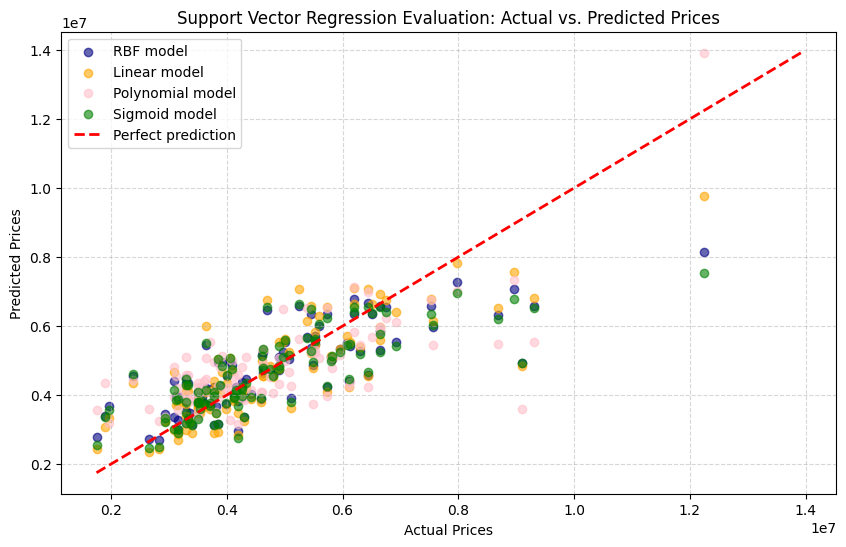

In [275]:
# Accurate Model Evaluation - Plotting Actual vs Predicted Prices
plt.figure(figsize=(10, 6))

# Scatter plots of predictions vs actual targets for each model
plt.scatter(ytest, y_rbf, color='navy', alpha=0.6, label='RBF model')
plt.scatter(ytest, y_lin, color='orange', alpha=0.6, label='Linear model')
plt.scatter(ytest, y_poly, color='pink', alpha=0.6, label='Polynomial model')
plt.scatter(ytest, y_sig, color='green', alpha=0.6, label='Sigmoid model')

# Calculate limits for the identity line
all_values = np.concatenate([ytest, y_rbf, y_lin, y_poly])
min_val, max_val = all_values.min(), all_values.max()

# Reference line representing perfect prediction (Actual = Predicted)
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect prediction')

plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Support Vector Regression Evaluation: Actual vs. Predicted Prices')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

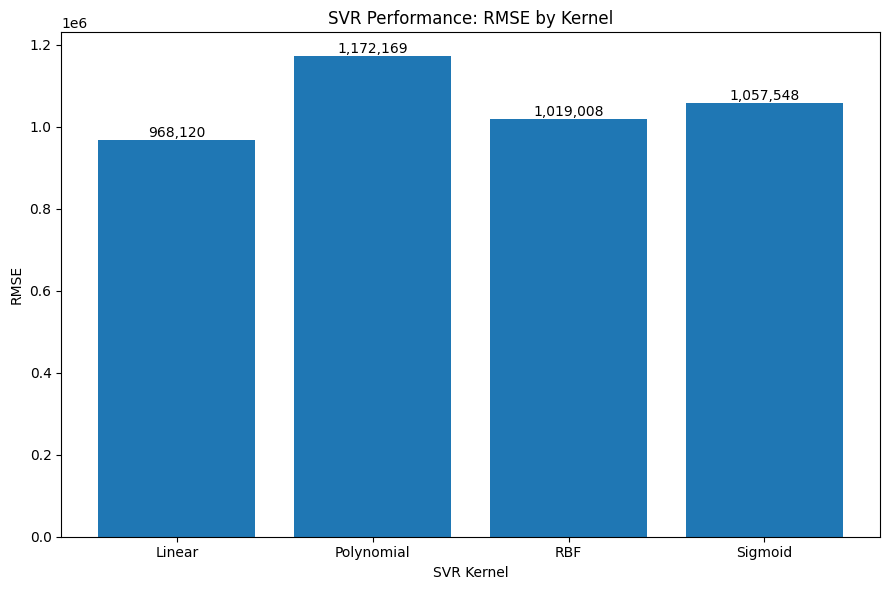

In [276]:
from sklearn.metrics import mean_squared_error

rmse_values = [
    np.sqrt(mean_squared_error(ytest, y_lin)),
    np.sqrt(mean_squared_error(ytest, y_poly)),
    np.sqrt(mean_squared_error(ytest, y_rbf)),
    np.sqrt(mean_squared_error(ytest, y_sig))
]

kernel_names = [
    "Linear",
    "Polynomial",
    "RBF",
    "Sigmoid"
]

plt.figure(figsize=(9, 6))

bars = plt.bar(kernel_names, rmse_values)

plt.xlabel("SVR Kernel")
plt.ylabel("RMSE")
plt.title("SVR Performance: RMSE by Kernel")

# Display values above bars
for bar, value in zip(bars, rmse_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()